In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df=pd.read_csv(r'C:\Users\jagan\Downloads\Super Store sales data\Superstore.csv')
print(df)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  2017-11-08  2017-11-11    Second Class   
1          2  CA-2017-152156  2017-11-08  2017-11-11    Second Class   
2          3  CA-2017-138688  2017-06-12  2017-06-16    Second Class   
3          4  US-2016-108966  2016-10-11  2016-10-18  Standard Class   
4          5  US-2016-108966  2016-10-11  2016-10-18  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2015-110422  2015-01-21  2015-01-23    Second Class   
9990    9991  CA-2018-121258  2018-02-26  2018-03-03  Standard Class   
9991    9992  CA-2018-121258  2018-02-26  2018-03-03  Standard Class   
9992    9993  CA-2018-121258  2018-02-26  2018-03-03  Standard Class   
9993    9994  CA-2018-119914  2018-05-04  2018-05-09    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United 

In [13]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [14]:
df = df.dropna(subset=['Postal Code'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])
df['Order Date']=pd.to_datetime(df['Order Date'])
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9983 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9983 non-null   int64         
 1   Order ID       9983 non-null   object        
 2   Order Date     9983 non-null   datetime64[ns]
 3   Ship Date      9983 non-null   datetime64[ns]
 4   Ship Mode      9983 non-null   object        
 5   Customer ID    9983 non-null   object        
 6   Customer Name  9983 non-null   object        
 7   Segment        9983 non-null   object        
 8   Country        9983 non-null   object        
 9   City           9983 non-null   object        
 10  State          9983 non-null   object        
 11  Postal Code    9983 non-null   float64       
 12  Region         9983 non-null   object        
 13  Product ID     9983 non-null   object        
 14  Category       9983 non-null   object        
 15  Sub-Category   9983 non-nu

In [15]:
low_discount=df[df['Discount']<=0.2]['Profit']
high_discount=df[df['Discount']>0.2]['Profit']
print('low discouunt mean profit: ',low_discount.mean())
print('High discouunt mean profit: ',high_discount.mean())

low discouunt mean profit:  48.839126821885905
High discouunt mean profit:  -97.1830983488873


In [16]:
t_stat, p_value = stats.ttest_ind(low_discount, high_discount)

print("T-Statistic:", t_stat)
print("P-value:", p_value)

T-Statistic: 22.114854514116594
P-value: 7.711397129739563e-106


In [17]:
if p_value < 0.05:
    print("Reject H0: High discounts significantly reduce profit.")
else:
    print("Fail to reject H0: No significant difference.")

Reject H0: High discounts significantly reduce profit.


In [19]:
print("Low Discount Mean Profit:", round(low_discount.mean(), 2))
print("High Discount Mean Profit:", round(high_discount.mean(), 2))
print("P-value:", p_value)

Low Discount Mean Profit: 48.84
High Discount Mean Profit: -97.18
P-value: 7.711397129739563e-106


In [20]:
import numpy as np

mean_diff = low_discount.mean() - high_discount.mean()
std_err = np.sqrt(low_discount.var()/len(low_discount) + high_discount.var()/len(high_discount))

ci_lower = mean_diff - 1.96 * std_err
ci_upper = mean_diff + 1.96 * std_err

print("Mean Difference:", round(mean_diff,2))
print("95% Confidence Interval:", (round(ci_lower,2), round(ci_upper,2)))

Mean Difference: 146.02
95% Confidence Interval: (np.float64(128.27), np.float64(163.78))


In [21]:
high_discount_loss_rate = (df[df['Discount'] > 0.2]['Profit'] < 0).mean()

print("Loss Rate in High Discount Orders:", round(high_discount_loss_rate*100,2), "%")

Loss Rate in High Discount Orders: 96.77 %


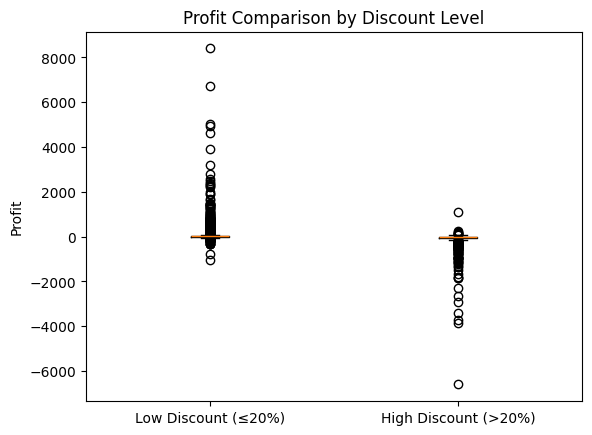

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot([low_discount, high_discount])
plt.xticks([1, 2], ['Low Discount (≤20%)', 'High Discount (>20%)'])
plt.title("Profit Comparison by Discount Level")
plt.ylabel("Profit")
plt.show()

In [23]:
loss_rate = (df[df['Discount'] > 0.2]['Profit'] < 0).mean()
print("High Discount Loss Rate:", round(loss_rate*100,2), "%")


High Discount Loss Rate: 96.77 %
